In [179]:
# === DATASET PARAMETERS
data_file          = "breast_cancer_diagnostic.csv"          
separator          = r","             
header             = None                  
target_is_last     = True              
positive_class_val = 2                   
skip_first_rows    = 1                 

In [180]:
import pandas as pd
import numpy as np
df = pd.read_csv(data_file, sep=separator, skiprows=skip_first_rows)
df = df.dropna()
print("Raw shape:", df.shape)
print("First row:\n", df.iloc[0])

Raw shape: (568, 32)
First row:
 842302      842517.000000
17.99           20.570000
10.38           17.770000
122.8          132.900000
1001          1326.000000
0.1184           0.084740
0.2776           0.078640
0.3001           0.086900
0.1471           0.070170
0.2419           0.181200
0.07871          0.056670
1.095            0.543500
0.9053           0.733900
8.589            3.398000
153.4           74.080000
0.006399         0.005225
0.04904          0.013080
0.05373          0.018600
0.01587          0.013400
0.03003          0.013890
0.006193         0.003532
25.38           24.990000
17.33           23.410000
184.6          158.800000
2019          1956.000000
0.1622           0.123800
0.6656           0.186600
0.7119           0.241600
0.2654           0.186000
0.4601           0.275000
0.1189           0.089020
1                1.000000
Name: 0, dtype: float64


In [181]:
X = df.iloc[:, :-1].values         
y_raw = df.iloc[:, -1].values     
y = np.where(y_raw == positive_class_val, 1, -1)

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (568, 31), y shape: (568,)


In [182]:
mu    = X.mean(axis=0)
sigma = X.std(axis=0)
sigma[sigma == 0] = 1        
X_norm = (X - mu) / sigma

print("Feature means (should be ~0):", X_norm.mean(axis=0).round(4))
print("Feature stds  (should be ~1):",  X_norm.std(axis=0).round(4))

Feature means (should be ~0): [-0. -0. -0. -0. -0. -0. -0.  0.  0. -0.  0.  0.  0.  0. -0. -0.  0.  0.
  0. -0. -0. -0. -0.  0.  0.  0. -0.  0.  0. -0. -0.]
Feature stds  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1.]


In [183]:

X_bias = np.hstack([np.ones((X_norm.shape[0], 1)), X_norm])


N   = X_bias.shape[0]
idx = np.random.permutation(N)
Ntr = int(0.6 * N)

Xtr, ytr = X_bias[idx[:Ntr]], y[idx[:Ntr]]
Xte, yte = X_bias[idx[Ntr:]], y[idx[Ntr:]]

print(f"Training samples : {Xtr.shape[0]}")
print(f"Testing  samples : {Xte.shape[0]}")
print(f"Feature dimension (incl. bias): {Xtr.shape[1]}")

Training samples : 340
Testing  samples : 228
Feature dimension (incl. bias): 32


In [184]:
def sigmoid(s):
   
    return np.where(
        s >= 0,
        1.0 / (1.0 + np.exp(-s)),
        np.exp(s) / (1.0 + np.exp(s))
    )

def train_logistic(X, y, lr=0.01, n_iter=5000):
 
    n, d = X.shape
    w = np.zeros(d)
    loss_history = []
    for i in range(n_iter):
        margins = y * X.dot(w)
        probs   = sigmoid(-margins)
        grad    = (X.T.dot(y * probs)) / n   
        w      += lr * grad                  
        if i % 500 == 0:
            nll = -np.log(sigmoid(margins) + 1e-5).mean()
            loss_history.append((i, nll))
    return w, loss_history

def predict_logistic(X, w):
   
    return np.sign(X.dot(w)).astype(int)
    
def train_logistic_track(X, y, lr=0.01, n_iter=5000):
    
    n, d = X.shape
    w = np.zeros(d)
    losses = []
    for _ in range(n_iter):
        margins = y * X.dot(w)
        probs   = sigmoid(-margins)
        grad    = (X.T.dot(y * probs)) / n
        w      += lr * grad
        losses.append(-np.log(sigmoid(margins) + 1e-5).mean())
    return w, losses

In [185]:
w, loss_history = train_logistic(Xtr, ytr, lr=0.01, n_iter=5000)

feature_names = ["bias"] + [f"x{i}" for i in range(1, len(w))]
print("Final weight vector w:")
for name, wi in zip(feature_names, w):
    print(f"  {name:12s}: {wi:+.6f}")

Final weight vector w:
  bias        : +0.403606
  x1          : -0.162465
  x2          : -0.518708
  x3          : -0.546511
  x4          : -0.505729
  x5          : -0.528339
  x6          : -0.267833
  x7          : +0.024128
  x8          : -0.481374
  x9          : -0.656676
  x10         : -0.006939
  x11         : +0.255625
  x12         : -0.710054
  x13         : -0.008402
  x14         : -0.541921
  x15         : -0.561867
  x16         : -0.089844
  x17         : +0.497797
  x18         : +0.185659
  x19         : -0.100241
  x20         : +0.200678
  x21         : +0.395769
  x22         : -0.675028
  x23         : -0.739967
  x24         : -0.628248
  x25         : -0.646879
  x26         : -0.602849
  x27         : -0.140369
  x28         : -0.428152
  x29         : -0.648473
  x30         : -0.569948
  x31         : -0.271541


In [186]:
y_pred = predict_logistic(Xte, w)

accuracy = (y_pred == yte).mean()
print("Predictions :", y_pred)
print("True labels :", yte)
print(f"\nTest Accuracy: {accuracy:.4f}  ({accuracy*100:.1f}%)")

Predictions : [-1  1 -1  1 -1  1  1 -1  1 -1  1 -1  1  1 -1  1 -1 -1  1 -1  1  1  1  1
  1  1  1 -1  1  1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1  1 -1  1 -1  1
  1  1  1 -1  1  1 -1  1  1 -1  1  1  1  1 -1 -1  1  1  1 -1  1  1 -1  1
 -1  1  1  1 -1 -1  1 -1  1  1 -1  1 -1 -1  1 -1  1  1 -1  1  1  1  1  1
  1 -1 -1  1  1 -1  1  1  1  1 -1  1 -1  1 -1  1 -1 -1 -1 -1  1 -1  1  1
  1  1  1  1  1 -1  1 -1  1  1  1  1 -1  1  1  1 -1  1  1  1 -1  1 -1  1
 -1 -1  1 -1 -1 -1  1  1  1  1 -1 -1  1  1 -1  1  1  1  1  1 -1 -1 -1  1
  1 -1  1  1 -1 -1  1 -1  1  1 -1 -1  1  1 -1  1  1 -1 -1  1  1  1 -1  1
  1 -1  1 -1 -1  1 -1 -1  1  1  1  1  1  1  1 -1  1 -1 -1 -1 -1  1  1 -1
 -1 -1  1  1 -1 -1  1  1 -1 -1 -1 -1]
True labels : [-1  1 -1  1 -1  1  1 -1  1 -1  1 -1  1  1 -1  1 -1 -1  1 -1  1  1  1  1
  1  1  1 -1  1  1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1  1 -1  1 -1  1
  1  1  1 -1  1  1 -1  1  1 -1  1  1  1  1 -1 -1  1  1  1 -1  1  1 -1  1
 -1  1  1  1 -1 -1  1 -1  1  1 -1  1 -1 -1  1 -1  1  1 -1 

In [187]:
TP = int(((y_pred ==  1) & (yte ==  1)).sum())
TN = int(((y_pred == -1) & (yte == -1)).sum())
FP = int(((y_pred ==  1) & (yte == -1)).sum())
FN = int(((y_pred == -1) & (yte ==  1)).sum())

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1        = (2 * precision * recall / (precision + recall)
             if (precision + recall) > 0 else 0.0)

print(f"  TN={TN}  FP={FP}\n  FN={FN}  TP={TP}\n")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.1f}%)")

  TN=89  FP=1
  FN=0  TP=138

Precision : 0.9928
Recall    : 1.0000
F1 Score  : 0.9964
Accuracy  : 0.9956  (99.6%)


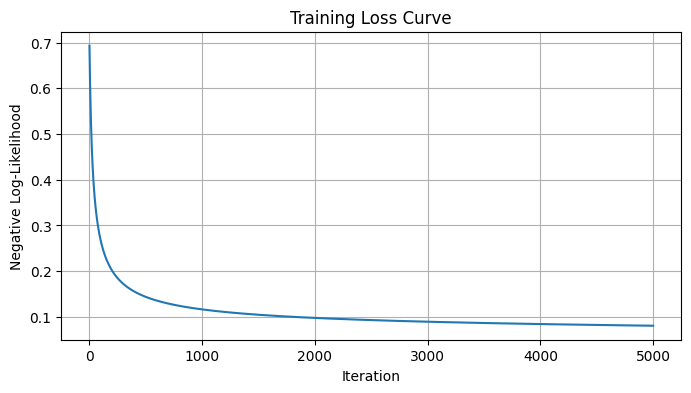

In [188]:
import matplotlib.pyplot as plt

_, losses = train_logistic_track(Xtr, ytr, lr=0.01, n_iter=5000)

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Negative Log-Likelihood")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()